In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import os
import cosmo as co

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [45]:
# color mapping for each order k
K_COLORS = ["C0", "C1", "C2", "C3", "C4", "C5"]


def plot_host_panel(ax, filepath, mass_threshold, zsample, kmax_plot=4):

    m = jsm_visualize.Arborist(
        file=filepath,
        merger_crit=-2,
        verbose=False
    )
    m.dendrochronology(mass_threshold=mass_threshold)

    x = np.log10(1 + zsample)
    # x = zsample

    # --- total counts ---
    ax.step(x, m.NAH_thresh / m.NAH[0], where="mid", color="k", lw=2)
    ax.step(x, m.NAH_z0 / m.NAH[0], where="mid", color="grey", lw=2)

    # --- per order k ---
    for k in range(min(kmax_plot, m.kmax)):
        ax.step(
            x,
            m.dendo_mat_thresh[:, k] / m.NAH[0],
            where="mid",
            color=K_COLORS[k],
            lw=1, label="k="+str(k+1), ls="--")


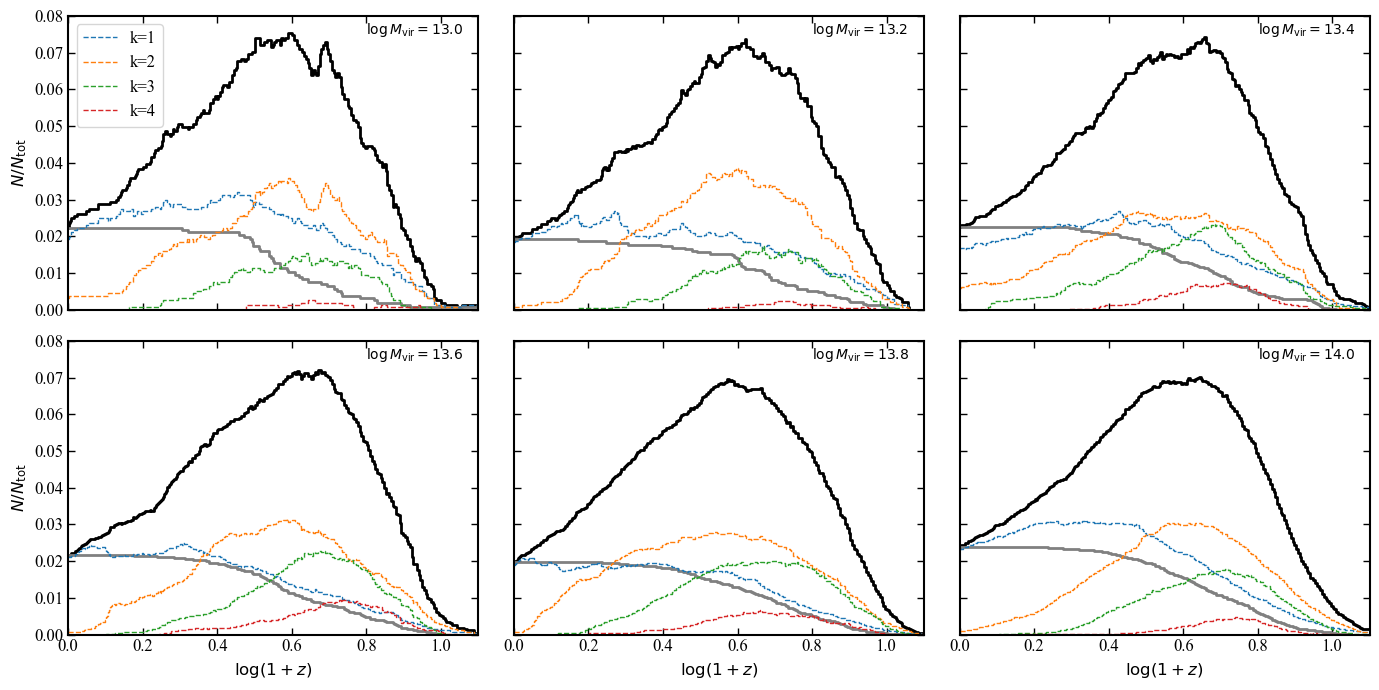

In [46]:
fig, ax = plt.subplots(
    2, 3,
    figsize=(2 * double_textwidth, double_textwidth),
    sharex=True,
    sharey=True
)

mass_bins = [13.0, 13.2, 13.4, 13.6, 13.8, 14.0]

# --------------------------------------------------
# Fill panels
# --------------------------------------------------
for i, mvir in enumerate(mass_bins):

    row = i // 3
    col = i % 3

    filepath = f"../../data/prelim/evolved_trees/tree_{mvir:.1f}.npz"

    plot_host_panel(
        ax[row, col],
        filepath,
        mass_threshold=6.75e9,
        zsample=cfg.zsample,
        kmax_plot=4
    )

    ax[row, col].text(0.8, 0.075, rf"$\log M_{{\rm vir}} = {mvir:.1f}$")

# --------------------------------------------------
# Axis labels
# --------------------------------------------------
for a in ax[-1, :]:
    a.set_xlabel(r'$\log (1+z)$')

for a in ax[:, 0]:
    a.set_ylabel(r'$N / N_{\rm tot}$')

# --------------------------------------------------
# X limits (adjust as appropriate for your zsample)
# --------------------------------------------------
ax[0,0].set_xlim(0, 1.1)
ax[0,0].set_ylim(0, 0.08)
ax[0,0].legend(loc=2)

# --------------------------------------------------
# Final layout
# --------------------------------------------------
plt.tight_layout()
plt.show()

In [31]:
bolshoi = pd.read_csv("../../data/summary_tabs/bolshoi.csv")
satgen = pd.read_csv("../../data/summary_tabs/SatGen_fid.csv")
# ave = pd.read_csv("../../data/summary_tabs/SatGen_ave.csv")
# Mcut = pd.read_csv("../../data/summary_tabs/SatGen_cut.csv")
# Rvir = pd.read_csv("../../data/summary_tabs/SatGen_Rvir.csv")

In [32]:
b140 = bolshoi[(13.9 < bolshoi["logMvir"]) & (bolshoi["logMvir"] < 14.1)]
b136 = bolshoi[(13.5 < bolshoi["logMvir"]) & (bolshoi["logMvir"] < 13.7)]
b132 = bolshoi[(13.1 < bolshoi["logMvir"]) & (bolshoi["logMvir"] < 13.3)]

In [33]:
Nsub_132 = 10**b132["logNsub"] / np.average(10**b132["logNsub"])
c_vir_132 = 10**b132["logc"] / np.average(10**b132["logc"])

Nsub_136 = 10**b136["logNsub"] / np.average(10**b136["logNsub"])
c_vir_136 = 10**b136["logc"] / np.average(10**b136["logc"])

Nsub_140 = 10**b140["logNsub"] / np.average(10**b140["logNsub"])
c_vir_140 = 10**b140["logc"] / np.average(10**b140["logc"])

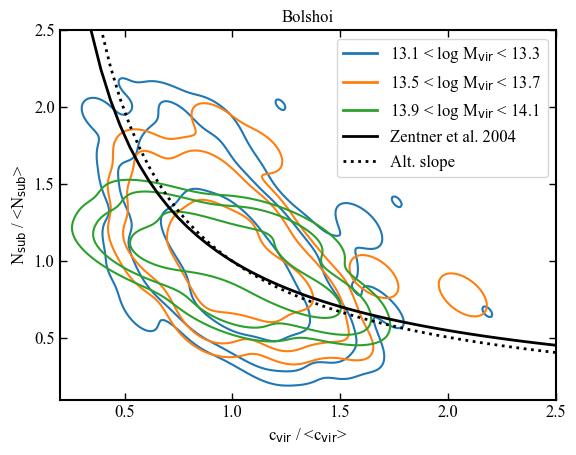

In [34]:

fig, ax = plt.subplots()

c_smooth = np.linspace(0.3, 2.5)

# KDE plots (store colors explicitly so legend matches)
kde1 = sns.kdeplot(x=c_vir_132, y=Nsub_132, levels=levelz, ax=ax, color="C0")
kde2 = sns.kdeplot(x=c_vir_136, y=Nsub_136, levels=levelz, ax=ax, color="C1")
kde3 = sns.kdeplot(x=c_vir_140, y=Nsub_140, levels=levelz, ax=ax, color="C2")

# Lines
line1, = ax.plot(c_smooth, c_smooth**(-0.86), lw=2, c="k")
line2, = ax.plot(c_smooth, c_smooth**(-0.98), lw=2, c="k", ls=":")

# Custom legend using Line2D
legend_elements = [
    Line2D([0], [0], color="C0", lw=2, label="13.1 < log M$_{\\rm vir}$ < 13.3"),
    Line2D([0], [0], color="C1", lw=2, label="13.5 < log M$_{\\rm vir}$ < 13.7"),
    Line2D([0], [0], color="C2", lw=2, label="13.9 < log M$_{\\rm vir}$ < 14.1"),
    Line2D([0], [0], color="k", lw=2, label="Zentner et al. 2004"),
    Line2D([0], [0], color="k", lw=2, ls=":", label="Alt. slope"),
]

ax.legend(handles=legend_elements)

ax.set_ylabel("N$_{\\rm sub}$ / <N$_{\\rm sub}$>")
ax.set_xlabel("c$_{\\rm vir}$ / <c$_{\\rm vir}$>")
ax.set_xlim(0.2, 2.5)
ax.set_ylim(0.1, 2.5)

ax.set_title("Bolshoi")
plt.show()

In [35]:
s140 = satgen[(13.9 < satgen["logMvir"]) & (satgen["logMvir"] < 14.1)]
s136 = satgen[(13.5 < satgen["logMvir"]) & (satgen["logMvir"] < 13.7)]
s132 = satgen[(13.1 < satgen["logMvir"]) & (satgen["logMvir"] < 13.3)]

In [36]:
Nsub_132 = 10**s132["logNsub"] / np.average(10**s132["logNsub"])
c_vir_132 = 10**s132["logc"] / np.average(10**s132["logc"])

Nsub_136 = 10**s136["logNsub"] / np.average(10**s136["logNsub"])
c_vir_136 = 10**s136["logc"] / np.average(10**s136["logc"])

Nsub_140 = 10**s140["logNsub"] / np.average(10**s140["logNsub"])
c_vir_140 = 10**s140["logc"] / np.average(10**s140["logc"])

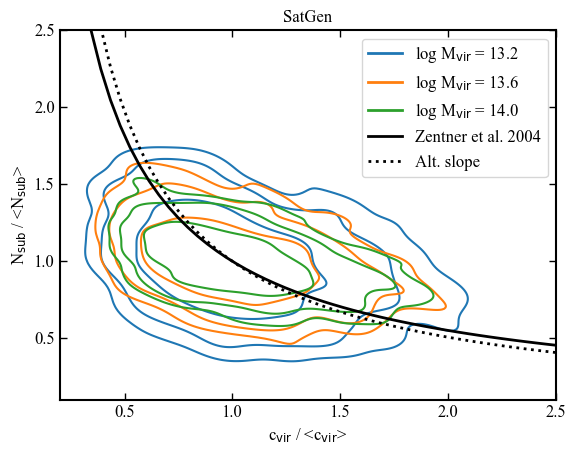

In [37]:

fig, ax = plt.subplots()

c_smooth = np.linspace(0.3, 2.5)

# KDE plots (store colors explicitly so legend matches)
kde1 = sns.kdeplot(x=c_vir_132, y=Nsub_132, levels=levelz, ax=ax, color="C0")
kde2 = sns.kdeplot(x=c_vir_136, y=Nsub_136, levels=levelz, ax=ax, color="C1")
kde3 = sns.kdeplot(x=c_vir_140, y=Nsub_140, levels=levelz, ax=ax, color="C2")

# Lines
line1, = ax.plot(c_smooth, c_smooth**(-0.86), lw=2, c="k")
line2, = ax.plot(c_smooth, c_smooth**(-0.98), lw=2, c="k", ls=":")

# Custom legend using Line2D
legend_elements = [
    Line2D([0], [0], color="C0", lw=2, label="log M$_{\\rm vir}$ = 13.2"),
    Line2D([0], [0], color="C1", lw=2, label="log M$_{\\rm vir}$ = 13.6"),
    Line2D([0], [0], color="C2", lw=2, label="log M$_{\\rm vir}$ = 14.0"),
    Line2D([0], [0], color="k", lw=2, label="Zentner et al. 2004"),
    Line2D([0], [0], color="k", lw=2, ls=":", label="Alt. slope"),
]

ax.legend(handles=legend_elements)

ax.set_ylabel("N$_{\\rm sub}$ / <N$_{\\rm sub}$>")
ax.set_xlabel("c$_{\\rm vir}$ / <c$_{\\rm vir}$>")
ax.set_xlim(0.2, 2.5)
ax.set_ylim(0.1, 2.5)

ax.set_title("SatGen")
plt.show()

In [38]:
def normalize_from_log(df, col):
    vals = 10**df[col]
    return vals / np.mean(vals)

def normalized_a50_from_logz(df):
    x = 10**df["logz50"]              # 1 + z50
    x_norm = x / np.mean(x)           # normalized (1 + z50)
    a50 = 1.0 / x_norm                # normalized a50
    return a50

Nsub_132 = normalize_from_log(b132, "logNsub")
Nsub_136 = normalize_from_log(b136, "logNsub")
Nsub_140 = normalize_from_log(b140, "logNsub")

z50_132_norm = normalize_from_log(b132, "logz50")
z50_136_norm = normalize_from_log(b136, "logz50")
z50_140_norm = normalize_from_log(b140, "logz50")

a50_132 = normalized_a50_from_logz(b132)
a50_136 = normalized_a50_from_logz(b136)
a50_140 = normalized_a50_from_logz(b140)

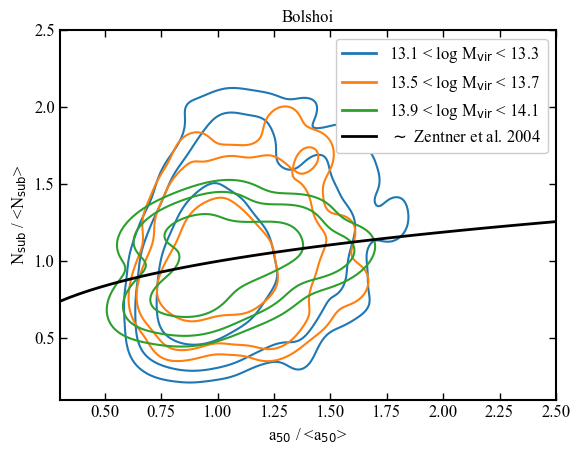

In [39]:
fig, ax = plt.subplots()

# KDE plots (store colors explicitly so legend matches)
kde1 = sns.kdeplot(x=a50_132, y=Nsub_132, levels=levelz, ax=ax, color="C0")
kde2 = sns.kdeplot(x=a50_136, y=Nsub_136, levels=levelz, ax=ax, color="C1")
kde3 = sns.kdeplot(x=a50_140, y=Nsub_140, levels=levelz, ax=ax, color="C2")


line1, = ax.plot(c_smooth, c_smooth**(0.25), lw=2, c="k")


# Custom legend using Line2D
legend_elements = [
    Line2D([0], [0], color="C0", lw=2, label="13.1 < log M$_{\\rm vir}$ < 13.3"),
    Line2D([0], [0], color="C1", lw=2, label="13.5 < log M$_{\\rm vir}$ < 13.7"),
    Line2D([0], [0], color="C2", lw=2, label="13.9 < log M$_{\\rm vir}$ < 14.1"),
    Line2D([0], [0], color="k", lw=2, label="$\\sim$ Zentner et al. 2004"),
]

# ax.legend(handles=legend_elements)

ax.set_ylabel("N$_{\\rm sub}$ / <N$_{\\rm sub}$>")
ax.set_xlabel("a$_{\\rm 50}$ / <a$_{\\rm 50}$>")
ax.set_xlim(0.3, 2.5)
ax.set_ylim(0.1, 2.5)
ax.legend(handles=legend_elements, framealpha=1)


ax.set_title("Bolshoi")
plt.show()

In [40]:
def normalize_from_log(df, col):
    vals = 10**df[col]
    return vals / np.mean(vals)

def normalized_a50_from_logz(df):
    x = 10**df["logz50"]              # 1 + z50
    x_norm = x / np.mean(x)           # normalized (1 + z50)
    a50 = 1.0 / x_norm                # normalized a50
    return a50

Nsub_132 = normalize_from_log(s132, "logNsub")
Nsub_136 = normalize_from_log(s136, "logNsub")
Nsub_140 = normalize_from_log(s140, "logNsub")

z50_132_norm = normalize_from_log(s132, "logz50")
z50_136_norm = normalize_from_log(s136, "logz50")
z50_140_norm = normalize_from_log(s140, "logz50")

a50_132 = normalized_a50_from_logz(s132)
a50_136 = normalized_a50_from_logz(s136)
a50_140 = normalized_a50_from_logz(s140)

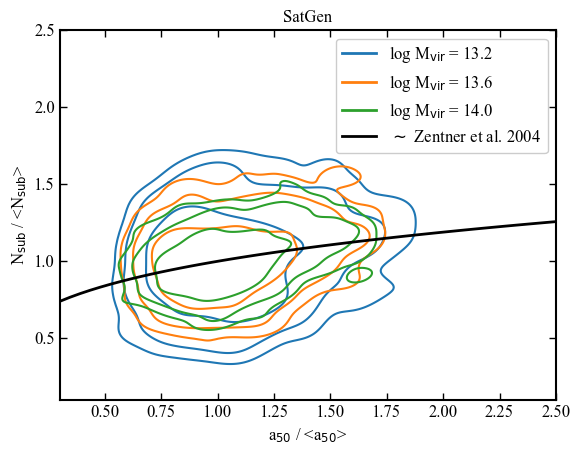

In [41]:
fig, ax = plt.subplots()

# KDE plots (store colors explicitly so legend matches)
kde1 = sns.kdeplot(x=a50_132, y=Nsub_132, levels=levelz, ax=ax, color="C0")
kde2 = sns.kdeplot(x=a50_136, y=Nsub_136, levels=levelz, ax=ax, color="C1")
kde3 = sns.kdeplot(x=a50_140, y=Nsub_140, levels=levelz, ax=ax, color="C2")


line1, = ax.plot(c_smooth, c_smooth**(0.25), lw=2, c="k")


# Custom legend using Line2D
legend_elements = [
    Line2D([0], [0], color="C0", lw=2, label="log M$_{\\rm vir}$ = 13.2"),
    Line2D([0], [0], color="C1", lw=2, label="log M$_{\\rm vir}$ = 13.6"),
    Line2D([0], [0], color="C2", lw=2, label="log M$_{\\rm vir}$ = 14.0"),
    Line2D([0], [0], color="k", lw=2, label="$\\sim$ Zentner et al. 2004"),
]

# ax.legend(handles=legend_elements)

ax.set_ylabel("N$_{\\rm sub}$ / <N$_{\\rm sub}$>")
ax.set_xlabel("a$_{\\rm 50}$ / <a$_{\\rm 50}$>")
ax.set_xlim(0.3, 2.5)
ax.set_ylim(0.1, 2.5)
ax.legend(handles=legend_elements, framealpha=1)


ax.set_title("SatGen")
plt.show()